In [13]:
from collections import namedtuple
from typing import Tuple

import os
import subprocess
import pickle
import numpy as np
import matplotlib.pyplot as plt

#### Utilities

In [14]:
ColorsCounts = namedtuple("ColorsCounts", ["boyerMyrvold", "mst", "cactus"])
Times = namedtuple("Times", ["boyerMyrvold", "mst", "cactus"])

AverageResult = namedtuple(
    "AverageResult",
    ["basic", "weighted"]
)

TestResult = namedtuple(
    "TestResult", 
    ["colors", "times"]
)

In [15]:
def test_minimal_coloring(n0: int, n: int, m: int, reps: int) -> Tuple[TestResult, TestResult] | None:
    try:
        result = subprocess.run(
            ["../build/minimum_coloring", str(5), str(n0), str(m), str(n), str(reps)],
            check=True,
            capture_output=True,
            text=True,
        )
    except subprocess.CalledProcessError as e:
        print(f"Error generating graph: {e}")
        return None
    
    output_lines = result.stdout.strip().splitlines()
    if len(output_lines) < 2:
        print("Unexpected output format")
        return None

    color_values = list(map(float, output_lines[0].split()))
    color_mean = AverageResult(
        basic=ColorsCounts(color_values[0], color_values[4], color_values[8]),
        weighted=ColorsCounts(color_values[2], color_values[6], color_values[10])
    )
    color_std = AverageResult(
        basic=ColorsCounts(color_values[1], color_values[5], color_values[9]),
        weighted=ColorsCounts(color_values[3], color_values[7], color_values[11])
    )

    time_values = list(map(float, output_lines[1].split()))
    time_mean = AverageResult(
        basic=Times(time_values[0], time_values[4], time_values[8]),
        weighted=Times(time_values[2], time_values[6], time_values[10])
    )
    time_std = AverageResult(
        basic=Times(time_values[1], time_values[5], time_values[9]),
        weighted=Times(time_values[3], time_values[7], time_values[11])
    )
    

    return TestResult(color_mean, time_mean), TestResult(color_std, time_std)

#### Minimum Coloring

In [16]:
GRAPH_N0 = 10
GRAPH_N_VALUES = list(range(50, 1000 + 1, 50))
GRAPH_M_VALUES = list(range(2, 5 + 1, 1))

REPETITIONS = 1
ALWAYS_REWRITE = True

In [17]:
for m in GRAPH_M_VALUES:
    output_filename = f"cache/minimum_coloring_m{m}.pkl"
    
    if os.path.exists(output_filename) and not ALWAYS_REWRITE:
        continue

    results = []
    for n in GRAPH_N_VALUES:
        result = test_minimal_coloring(GRAPH_N0, n, m, REPETITIONS)
        if not result:
            print("Experiment failed")
            exit(1)
        
        results.append(result)

    with open(output_filename, "wb") as f:
        pickle.dump((GRAPH_N_VALUES, results), f)

[TestResult(colors=AverageResult(basic=ColorsCounts(boyerMyrvold=2.0, mst=2.0, cactus=2.0), weighted=ColorsCounts(boyerMyrvold=2.0, mst=2.0, cactus=2.0)), times=AverageResult(basic=Times(boyerMyrvold=0.000539119, mst=0.00176268, cactus=0.00256463), weighted=Times(boyerMyrvold=0.000704599, mst=0.00235376, cactus=0.00208704))), TestResult(colors=AverageResult(basic=ColorsCounts(boyerMyrvold=2.0, mst=2.0, cactus=2.0), weighted=ColorsCounts(boyerMyrvold=2.0, mst=2.0, cactus=2.0)), times=AverageResult(basic=Times(boyerMyrvold=0.00544219, mst=0.00453389, cactus=0.00413143), weighted=Times(boyerMyrvold=0.00424525, mst=0.00527303, cactus=0.0057457))), TestResult(colors=AverageResult(basic=ColorsCounts(boyerMyrvold=3.0, mst=2.0, cactus=2.0), weighted=ColorsCounts(boyerMyrvold=3.0, mst=2.0, cactus=2.0)), times=AverageResult(basic=Times(boyerMyrvold=0.0115045, mst=0.015622, cactus=0.0121951), weighted=Times(boyerMyrvold=0.00805839, mst=0.0156062, cactus=0.0151663))), TestResult(colors=AverageResu

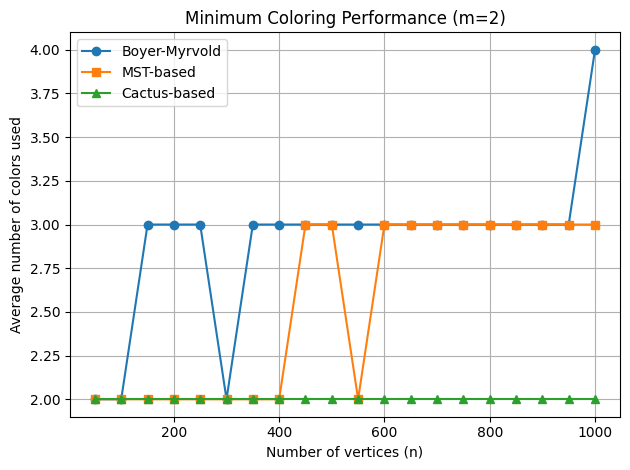

[TestResult(colors=AverageResult(basic=ColorsCounts(boyerMyrvold=2.0, mst=2.0, cactus=2.0), weighted=ColorsCounts(boyerMyrvold=2.0, mst=2.0, cactus=2.0)), times=AverageResult(basic=Times(boyerMyrvold=0.00167922, mst=0.00307126, cactus=0.00201155), weighted=Times(boyerMyrvold=0.00195716, mst=0.00152305, cactus=0.00199209))), TestResult(colors=AverageResult(basic=ColorsCounts(boyerMyrvold=3.0, mst=2.0, cactus=3.0), weighted=ColorsCounts(boyerMyrvold=3.0, mst=3.0, cactus=3.0)), times=AverageResult(basic=Times(boyerMyrvold=0.00751321, mst=0.00852727, cactus=0.0088152), weighted=Times(boyerMyrvold=0.00706043, mst=0.0073168, cactus=0.00839815))), TestResult(colors=AverageResult(basic=ColorsCounts(boyerMyrvold=3.0, mst=3.0, cactus=3.0), weighted=ColorsCounts(boyerMyrvold=3.0, mst=3.0, cactus=3.0)), times=AverageResult(basic=Times(boyerMyrvold=0.0164512, mst=0.0197515, cactus=0.0167554), weighted=Times(boyerMyrvold=0.0152552, mst=0.0160467, cactus=0.0175333))), TestResult(colors=AverageResult(

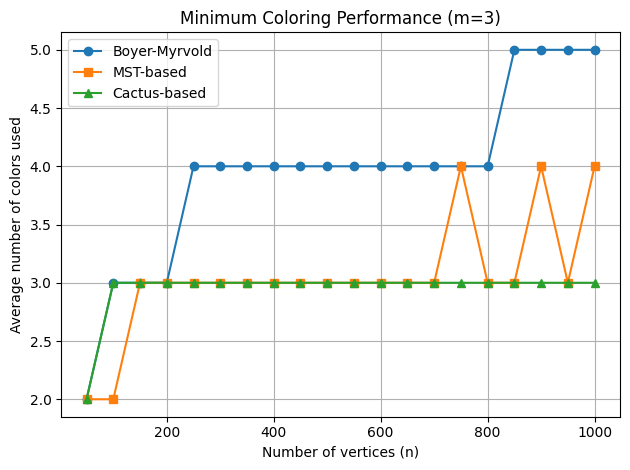

[TestResult(colors=AverageResult(basic=ColorsCounts(boyerMyrvold=3.0, mst=3.0, cactus=3.0), weighted=ColorsCounts(boyerMyrvold=3.0, mst=3.0, cactus=3.0)), times=AverageResult(basic=Times(boyerMyrvold=0.00209286, mst=0.00292361, cactus=0.00276047), weighted=Times(boyerMyrvold=0.00231864, mst=0.00257456, cactus=0.00284931))), TestResult(colors=AverageResult(basic=ColorsCounts(boyerMyrvold=3.0, mst=3.0, cactus=3.0), weighted=ColorsCounts(boyerMyrvold=3.0, mst=3.0, cactus=3.0)), times=AverageResult(basic=Times(boyerMyrvold=0.0106044, mst=0.0135072, cactus=0.0114185), weighted=Times(boyerMyrvold=0.0109517, mst=0.0106189, cactus=0.011963))), TestResult(colors=AverageResult(basic=ColorsCounts(boyerMyrvold=4.0, mst=3.0, cactus=3.0), weighted=ColorsCounts(boyerMyrvold=4.0, mst=4.0, cactus=4.0)), times=AverageResult(basic=Times(boyerMyrvold=0.0285217, mst=0.0327946, cactus=0.0279003), weighted=Times(boyerMyrvold=0.0295174, mst=0.026726, cactus=0.0304114))), TestResult(colors=AverageResult(basic=

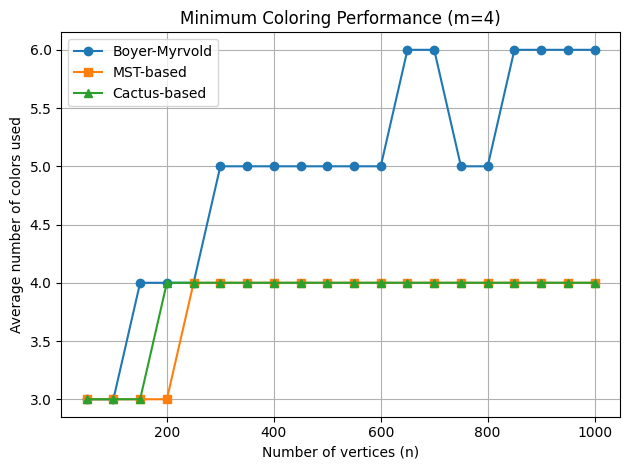

[TestResult(colors=AverageResult(basic=ColorsCounts(boyerMyrvold=3.0, mst=3.0, cactus=3.0), weighted=ColorsCounts(boyerMyrvold=3.0, mst=3.0, cactus=3.0)), times=AverageResult(basic=Times(boyerMyrvold=0.00392934, mst=0.00500736, cactus=0.00492113), weighted=Times(boyerMyrvold=0.00411861, mst=0.00457265, cactus=0.00537485))), TestResult(colors=AverageResult(basic=ColorsCounts(boyerMyrvold=4.0, mst=4.0, cactus=4.0), weighted=ColorsCounts(boyerMyrvold=4.0, mst=4.0, cactus=4.0)), times=AverageResult(basic=Times(boyerMyrvold=0.0197095, mst=0.0266796, cactus=0.0251263), weighted=Times(boyerMyrvold=0.0202712, mst=0.0225347, cactus=0.0262367))), TestResult(colors=AverageResult(basic=ColorsCounts(boyerMyrvold=4.0, mst=4.0, cactus=4.0), weighted=ColorsCounts(boyerMyrvold=4.0, mst=4.0, cactus=4.0)), times=AverageResult(basic=Times(boyerMyrvold=0.0566548, mst=0.0606684, cactus=0.0596799), weighted=Times(boyerMyrvold=0.0609091, mst=0.0554273, cactus=0.0629971))), TestResult(colors=AverageResult(basi

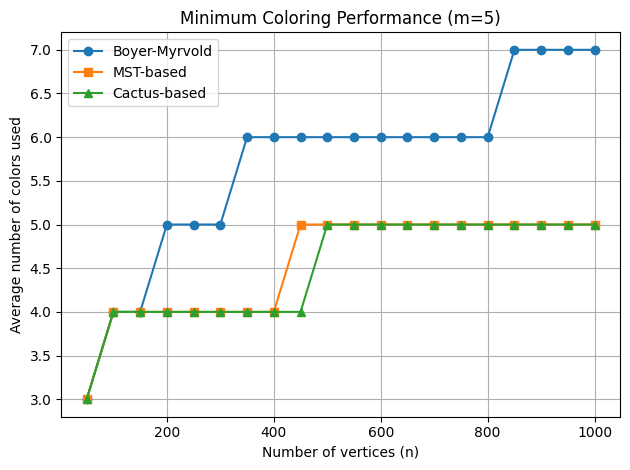

In [22]:
for m in GRAPH_M_VALUES:
    with open(f"cache/minimum_coloring_m{m}.pkl", "rb") as f:
        n_values, results = pickle.load(f)

    results_mean = [r[0] for r in results]
    results_std  = [r[1] for r in results]

    basic_boyer_colors = [res.colors.basic.boyerMyrvold for res in results_mean]
    basic_mst_colors    = [res.colors.basic.mst for res in results_mean]
    basic_cactus_colors = [res.colors.basic.cactus for res in results_mean]

    weighted_boyer_colors= [res.colors.weighted.boyerMyrvold for res in results_mean]
    weighted_mst_colors    = [res.colors.weighted.mst for res in results_mean]
    weighted_cactus_colors = [res.colors.weighted.cactus for res in results_mean]

    plt.plot(n_values, basic_boyer_colors, label="Boyer-Myrvold", marker='o')
    plt.plot(n_values, basic_mst_colors, label="MST-based", marker='s')
    plt.plot(n_values, basic_cactus_colors, label="Cactus-based", marker='^')
    plt.xlabel("Number of vertices (n)")
    plt.ylabel("Average number of colors used")
    plt.title(f"Minimum Coloring Performance (m={m})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()